This notebook presents a quick demonstration of the wealth-in-utility model with portfolio choice. It shows two results:

1) In a sample of 10,000 simulated agents, the percentiles of the distribution of risky asset share are stable / smooth by age, without jags or jumps.
2) Within each simulated agent, consumption is also fairly smooth from year to year.

To begin, let's import the tools we need from HARK (and general Python packages).

In [1]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
from time import time

# Our microeconomic model of interest
from HARK.models import WealthPortfolioConsumerType

# Some tools from HARK
from HARK.utilities import get_percentiles
from HARK.Calibration import (
    Cagetti_income,
    parse_income_spec,
    parse_time_params,
    parse_ssa_life_table,
)

mystr = lambda x: "{:.4f}".format(x)

Now we specify a dictionary that describes the life-cycle of our agents, including their income growth profile, income risk, and mortality processes. We also specify the major preference parameters, but there are many more parameters for the model that we (implicitly) leave at their default values.

In [2]:
# Define a life-cycle calibration using HARK tools
birth_age = 22
death_age = 115
sim_until_age = 95
T_sim = sim_until_age - birth_age

# Build income specification
income_params = parse_income_spec(
    age_min=birth_age,
    age_max=death_age,
    adjust_infl_to=1992,
    **Cagetti_income["College"],
)

# Build survival and time specification
liv_prb = parse_ssa_life_table(
    female=False, cross_sec=True, year=2004, age_min=birth_age, age_max=death_age
)
time_params = parse_time_params(age_birth=birth_age, age_death=death_age)

# Some specific parameters we might be interested in changing
my_params = {
    "DiscFac": 0.96,  # intertemporal discount factor
    "CRRA": 4.5,  # coefficient of relative risk aversion
    "WealthShift": 0.0,  # additive shifter term for wealth-in-utility
    "WealthShare": 0.2,  # share of wealth in Cobb-Douglas combination
    "AgentCount": 10000,  # number of agents to simulate
    "T_sim": T_sim,  # number of periods to simulate
}

# Put it all together into one dictionary
lifecycle_dict = income_params.copy()
lifecycle_dict["LivPrb"] = liv_prb
lifecycle_dict.update(**time_params)
lifecycle_dict.update(**my_params)
lifecycle_dict["Rfree"] = lifecycle_dict["T_cycle"] * [1.03]
lifecycle_dict["UnempPrbRet"] = 0.0  # Turn off possibility of missing SS benefits

Now we can create an instance of `WealthPortfolioConsumerType`, giving it the parameter dictionary that we specified, and then solve its life-cycle.

In [3]:
# Make and solve a wealth-in-utility portfolio choice consumer over their life-cycle
t0 = time()
MyType = WealthPortfolioConsumerType(**lifecycle_dict)
MyType.solve()
t1 = time()

print("Building and solving that model took + " + mystr(t1 - t0) + " seconds.")

Building and solving that model took + 0.7412 seconds.


With the model solved, we now simulate 10,000 individual agents of this type, giving each of them their own idiosyncratic sequence of shocks over their lifetime. Because we're interested in model outcomes at high ages, we turn off death and replacement by using the `stop_dead=False` option.

In [4]:
# Simulate 10,000 life-cycles, turning off mortality
t0 = time()
MyType.initialize_sym(stop_dead=False)
MyType.symulate()
t1 = time()

print("Simulating 10,000 agents until age 95 took " + mystr(t1 - t0) + " seconds.")

Simulating 10,000 agents until age 95 took 0.9902 seconds.


For convenient typing, let's extract the history arrays of simulated outcomes and give them short names. Each of these arrays are shape (73,10000), representing each simulated age for each of the 10,000 agents.

In [5]:
# Extract simulated histories of risky asset share, along with consumption and permanent income
S = MyType.hystory["Share"]
c = MyType.hystory["cNrm"]
p = MyType.hystory["pLvl"]
C = c * p  # re-normalize consumption to recover levels

In addition to the percentiles of risky share by age, let's also calculate the mean by age.

In [6]:
# Calculate the mean risky asset share by age
Share_mean = np.mean(S, axis=1)

# Extract 10th, 25th, 50th, 75th, and 90th percentiles of risky asset share by age
my_pctls = [0.1, 0.25, 0.5, 0.75, 0.9]
K = len(my_pctls)
Share_pctls = np.zeros((T_sim, K))
for t in range(T_sim):
    Share_pctls[t, :] = get_percentiles(S[t, :], percentiles=my_pctls)

# Make a vector of ages
age_vec = np.arange(birth_age, sim_until_age)

Now we can plot those percentiles (and the mean) and see that they are fairly smooth with respect to age.

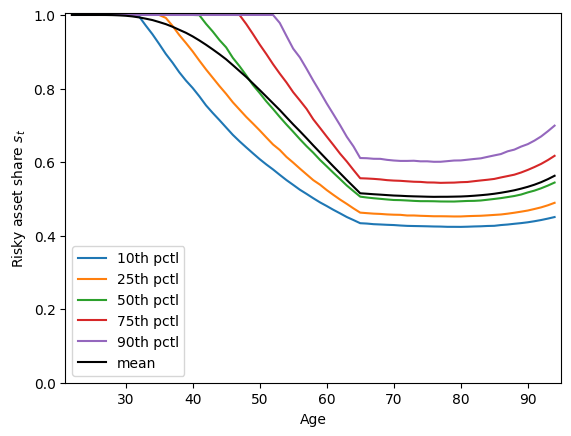

In [7]:
# Plot those percentiles
plt.xlim(birth_age - 1, sim_until_age)
plt.ylim(0.0, 1.005)
plt.xlabel("Age")
plt.ylabel(r"Risky asset share $s_t$")
plt.plot(age_vec, Share_pctls)
plt.plot(age_vec, Share_mean, "-k")
plt.legend(
    ["10th pctl", "25th pctl", "50th pctl", "75th pctl", "90th pctl", "mean"], loc=3
)
plt.show()

Now let's look at how volatile individual consumption is over the life-cycle. To do this, let's consider the proportional change in consumption for each simulated agent in each period, and then compute its mean and standard deviation by age. The mean change tells us about the general life-cycle trend for consumption, while the standard deviation speaks to unexpected fluctuations-- deviations from the average life-cycle path.

In [8]:
# Calculate relative change in consumption for each agent
C_t = C[1:, :]
C_tm1 = C[:-1, :]
C_delta = C_t - C_tm1
C_gro = C_delta / C_tm1

# Calculate age-conditional mean and standard deviation for consumption growth, and rescale to percentage
C_gro_mean = np.mean(C_gro, axis=1) * 100
C_gro_std = np.std(C_gro, axis=1) * 100

When we plot those statistics, we can see that idiosyncratic consumption does change from year to year, but is fairly smooth.

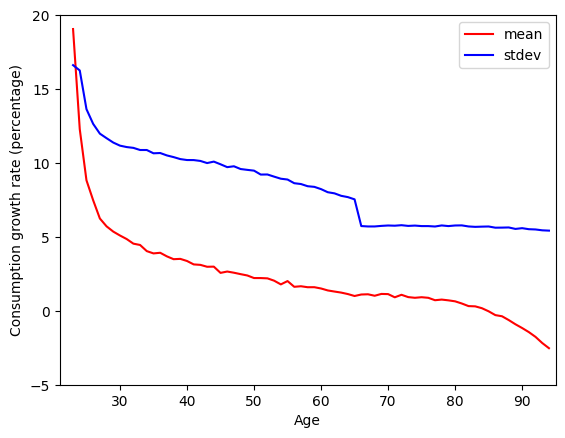

In [9]:
# Plot mean and standard deviation of consumption growth by age
plt.xlim(birth_age - 1, sim_until_age)
plt.ylim(-5.0, 20.0)
plt.xlabel("Age")
plt.ylabel(r"Consumption growth rate (percentage)")
plt.plot(age_vec[1:], C_gro_mean, "-r", label="mean")
plt.plot(age_vec[1:], C_gro_std, "-b", label="stdev")
plt.legend()
plt.show()

Mean consumption growth is high when young because it starts from a low level. Agents enter the model with (roughly) zero wealth, and want to accumulate a buffer to protect themselves from needing to make large changes to their consumption in response to income shocks. Within a few periods, the mean growth pattern has settled into a standard life-cycle profile. Note that consumption keeps growing even in early retirement, and only begins falling once agents reach their late 80's and have survived longer than expected.

The standard deviation of consumption growth is also high when young, because the agents are operating on the highly concave region of the consumption function and have a relatively high marginal propensity to consume, so income shocks transmit more strongly into consumption fluctuations. Once the agents build a buffer of wealth, their consumption is more insulated from income shocks and consumption volatility steadily falls. At age 65, there is a sharp drop in the standard deviation because everyone retires immediately, eliminating income shocks entirely. In the retirement years, consumption volatility is driven entirely by risky portfolio returns, averaging about 6%. That feels pretty reasonable to me.